# 1. Introduction




This dataset contains metadata about stock market securities listed on different exchanges. Each row represents one stock, ETF, or financial security.

The goal of this analysis is to:

Understand the dataset structure
Clean the dataset properly
Explore numerical and categorical variables
Find meaningful patterns and relationships
Generate insights that can help in decision-making

# 2. Import Required Libraries


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Better visualization
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 3. Load Dataset

In [5]:
# Load dataset
df = pd.read_csv('symbols_valid_meta.csv')

# First 5 rows
print(df.head())

  Nasdaq Traded Symbol                                      Security Name  \
0             Y      A            Agilent Technologies, Inc. Common Stock   
1             Y     AA                    Alcoa Corporation Common Stock    
2             Y   AAAU                       Perth Mint Physical Gold ETF   
3             Y   AACG  ATA Creativity Global - American Depositary Sh...   
4             Y   AADR                AdvisorShares Dorsey Wright ADR ETF   

  Listing Exchange Market Category ETF  Round Lot Size Test Issue  \
0                N                   N           100.0          N   
1                N                   N           100.0          N   
2                P                   Y           100.0          N   
3                Q               G   N           100.0          N   
4                P                   Y           100.0          N   

  Financial Status CQS Symbol NASDAQ Symbol NextShares  
0              NaN          A             A          N  
1       

# 4. Shape of Dataset

In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (8049, 12)


# 5. Dataset Overview

In [7]:
# General information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8049 entries, 0 to 8048
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nasdaq Traded     8049 non-null   object 
 1   Symbol            8049 non-null   object 
 2   Security Name     8049 non-null   object 
 3   Listing Exchange  8049 non-null   object 
 4   Market Category   8049 non-null   object 
 5   ETF               8049 non-null   object 
 6   Round Lot Size    8049 non-null   float64
 7   Test Issue        8049 non-null   object 
 8   Financial Status  3383 non-null   object 
 9   CQS Symbol        4666 non-null   object 
 10  NASDAQ Symbol     8049 non-null   object 
 11  NextShares        8049 non-null   object 
dtypes: float64(1), object(11)
memory usage: 754.7+ KB
None


In [8]:
# Statistical summary
print(df.describe(include='all'))

       Nasdaq Traded Symbol                                Security Name  \
count           8049   8049                                         8049   
unique             1   8049                                         8045   
top                Y      A  Urstadt Biddle Properties Inc. Common Stock   
freq            8049      1                                            2   
mean             NaN    NaN                                          NaN   
std              NaN    NaN                                          NaN   
min              NaN    NaN                                          NaN   
25%              NaN    NaN                                          NaN   
50%              NaN    NaN                                          NaN   
75%              NaN    NaN                                          NaN   
max              NaN    NaN                                          NaN   

       Listing Exchange Market Category   ETF  Round Lot Size Test Issue  \
count      

In [9]:
# Column names
print(df.columns)

Index(['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange',
       'Market Category', 'ETF', 'Round Lot Size', 'Test Issue',
       'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares'],
      dtype='object')


# 6. Understanding Each Column

# 7. Initial Business Understanding

# 8. Hypothesis Before Reading Data
These are assumptions made before detailed analysis.

# 9. Check Missing Values

In [10]:
# Missing values count
print(df.isnull().sum())

Nasdaq Traded          0
Symbol                 0
Security Name          0
Listing Exchange       0
Market Category        0
ETF                    0
Round Lot Size         0
Test Issue             0
Financial Status    4666
CQS Symbol          3383
NASDAQ Symbol          0
NextShares             0
dtype: int64


# 10. Check Duplicate Rows

In [11]:

# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


# 11. Fix Data Types

In [12]:
print(df.dtypes)

Nasdaq Traded        object
Symbol               object
Security Name        object
Listing Exchange     object
Market Category      object
ETF                  object
Round Lot Size      float64
Test Issue           object
Financial Status     object
CQS Symbol           object
NASDAQ Symbol        object
NextShares           object
dtype: object


In [13]:
# Convert data type
df['Round Lot Size'] = df['Round Lot Size'].astype(int)

# 12. Handle Missing Values Properly

##  Financial Status

In [14]:
# Fill missing values
df['Financial Status'] = df['Financial Status'].fillna('Unknown')

##  CQS Symbol

In [15]:
# Fill missing CQS symbols using NASDAQ symbol
df['CQS Symbol'] = df['CQS Symbol'].fillna(df['NASDAQ Symbol'])

# 13. Check Inconsistencies

## Compare Symbol and NASDAQ Symbol

In [16]:
comparison = (df['Symbol'] == df['NASDAQ Symbol']).value_counts()
print(comparison)

True     8046
False       3
Name: count, dtype: int64


## Compare Symbol and CQS Symbol

In [17]:
comparison2 = (df['Symbol'] == df['CQS Symbol']).value_counts()
print(comparison2)

True     8046
False       3
Name: count, dtype: int64


# 14. Final Dataset Check

In [18]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8049 entries, 0 to 8048
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Nasdaq Traded     8049 non-null   object
 1   Symbol            8049 non-null   object
 2   Security Name     8049 non-null   object
 3   Listing Exchange  8049 non-null   object
 4   Market Category   8049 non-null   object
 5   ETF               8049 non-null   object
 6   Round Lot Size    8049 non-null   int64 
 7   Test Issue        8049 non-null   object
 8   Financial Status  8049 non-null   object
 9   CQS Symbol        8049 non-null   object
 10  NASDAQ Symbol     8049 non-null   object
 11  NextShares        8049 non-null   object
dtypes: int64(1), object(11)
memory usage: 754.7+ KB
None
Nasdaq Traded       0
Symbol              0
Security Name       0
Listing Exchange    0
Market Category     0
ETF                 0
Round Lot Size      0
Test Issue          0
Financial Statu

# 15. Univariate Analysis

## Chart 1: Distribution of Round Lot Size (Histogram)

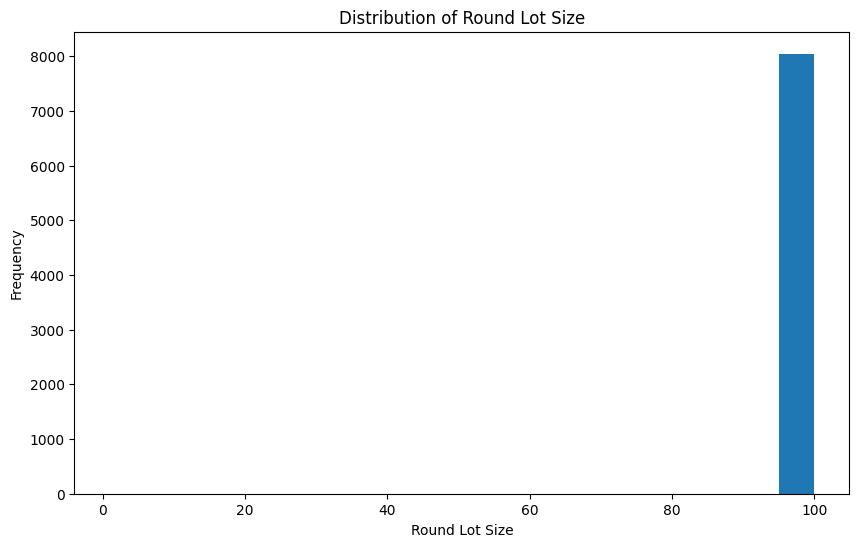

In [20]:
plt.hist(df['Round Lot Size'], bins=20)
plt.title('Distribution of Round Lot Size')
plt.xlabel('Round Lot Size')
plt.ylabel('Frequency')
plt.show()

## Chart 2: ETF Distribution (Count Plot)

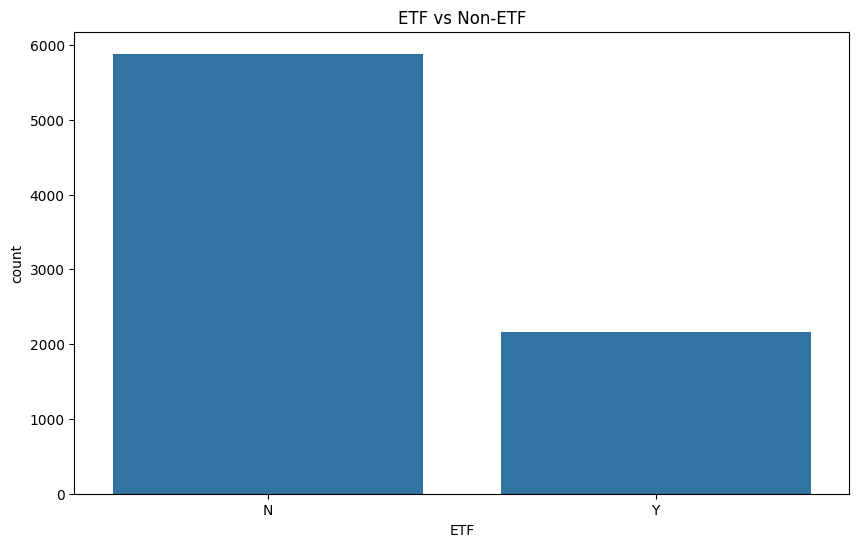

In [21]:
sns.countplot(x='ETF', data=df)
plt.title('ETF vs Non-ETF')
plt.show()

Non-ETF securities dominate the dataset.
An Exchange Traded Fund (ETF) is an investment fund that is traded in the stock market just like a normal share or stock.

## Chart 3: Listing Exchange Distribution

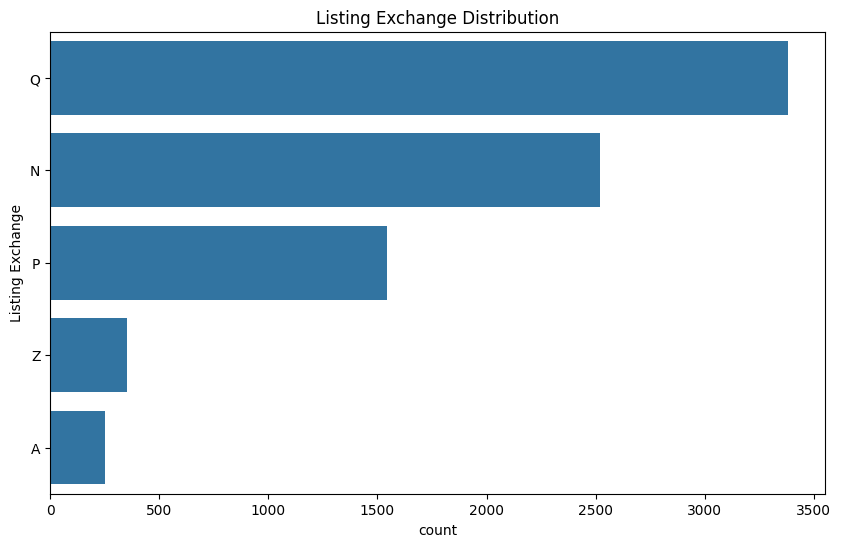

In [22]:
sns.countplot(y='Listing Exchange', data=df, order=df['Listing Exchange'].value_counts().index)
plt.title('Listing Exchange Distribution')
plt.show()

## Chart 4: Nasdaq Traded Distribution

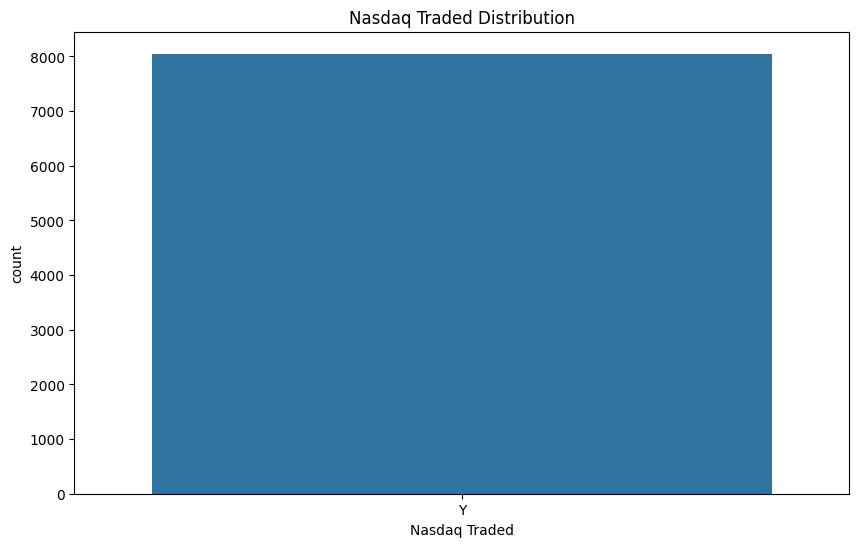

In [23]:
sns.countplot(x='Nasdaq Traded', data=df)
plt.title('Nasdaq Traded Distribution')
plt.show()

Most securities are Nasdaq traded.
Dataset me kitne stocks NASDAQ par trade hote hain aur kitne nahi.
Yes → Stock NASDAQ par trade hota hai

## Chart 5: Test Issue Distribution

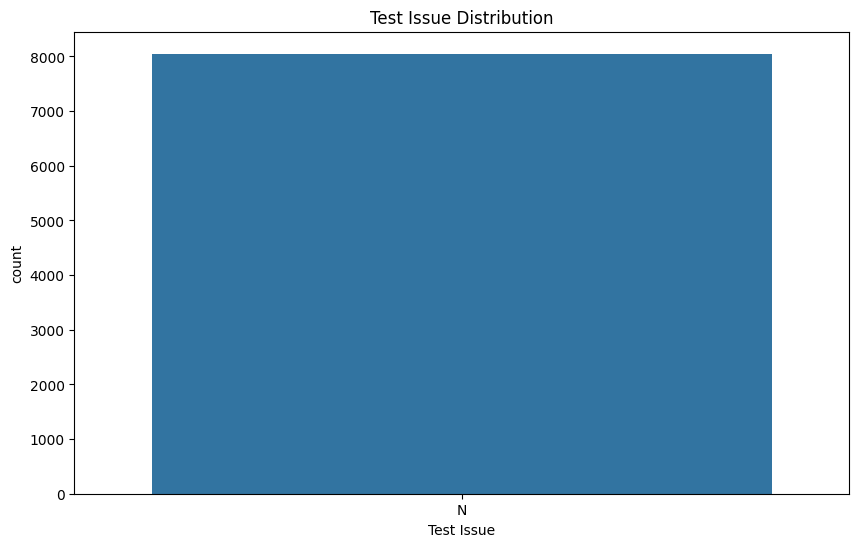

In [24]:
sns.countplot(x='Test Issue', data=df)
plt.title('Test Issue Distribution')
plt.show()

## Chart 6: Financial Status Distribution

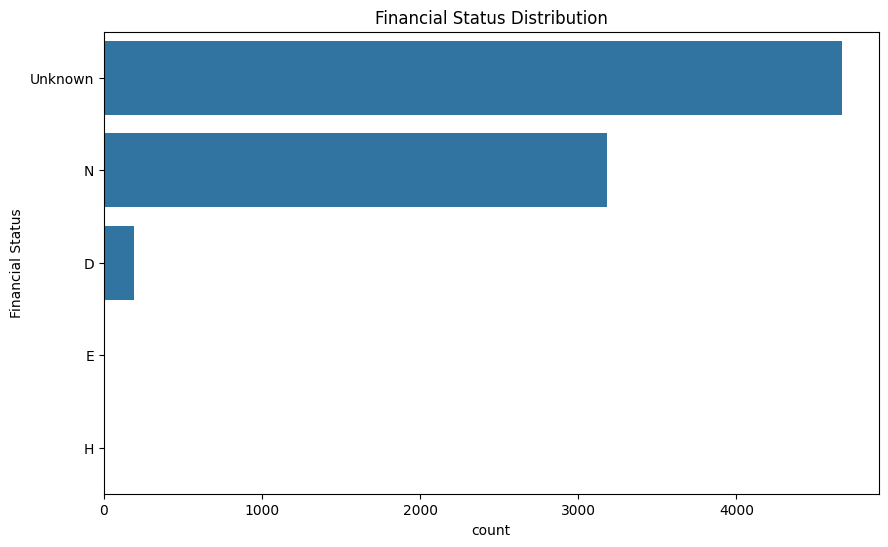

In [25]:
sns.countplot(y='Financial Status', data=df, order=df['Financial Status'].value_counts().index)
plt.title('Financial Status Distribution')
plt.show()

## Chart 7: NextShares Distribution

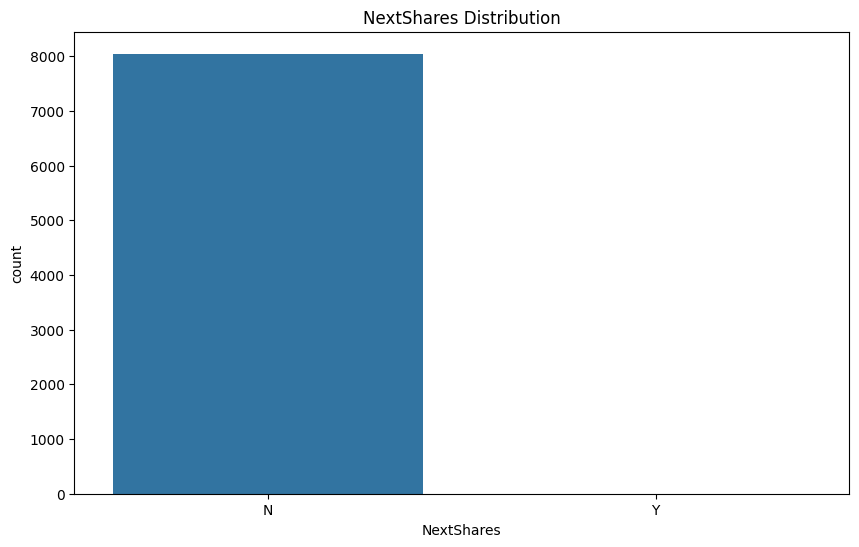

In [26]:
sns.countplot(x='NextShares', data=df)
plt.title('NextShares Distribution')
plt.show()

## Chart 8: Market Category Distribution

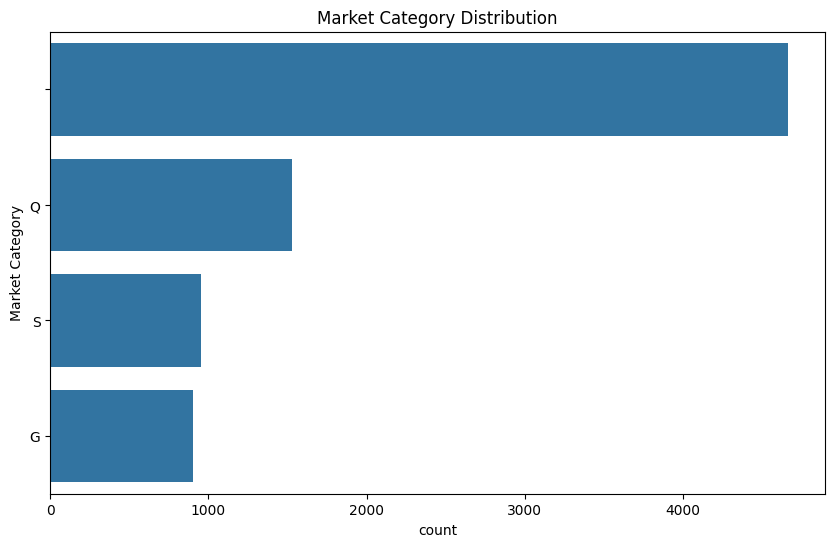

In [27]:
sns.countplot(y='Market Category', data=df, order=df['Market Category'].value_counts().index)
plt.title('Market Category Distribution')
plt.show()

## Chart 9: Top 15 Most Common First Letters of Symbols

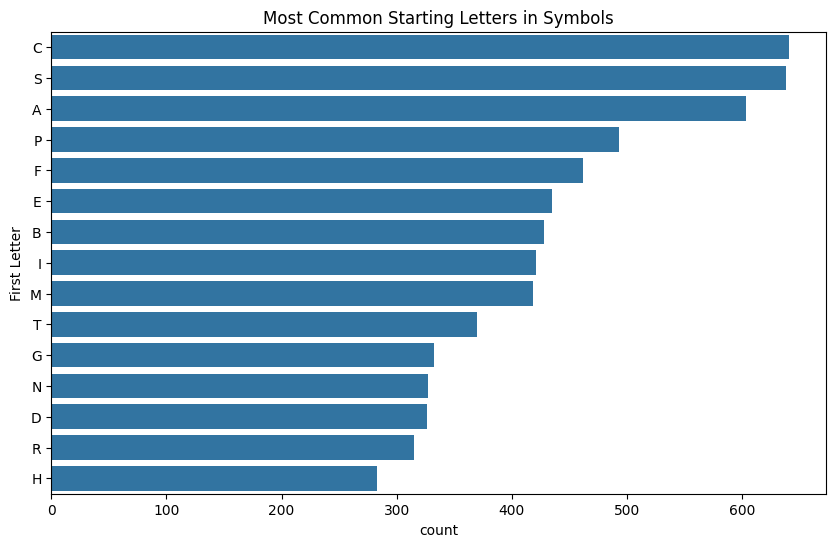

In [28]:
# Create first letter column
df['First Letter'] = df['Symbol'].str[0]

sns.countplot(y='First Letter', data=df,
              order=df['First Letter'].value_counts().index[:15])

plt.title('Most Common Starting Letters in Symbols')
plt.show()

## Chart 10: Security Name Length Distribution

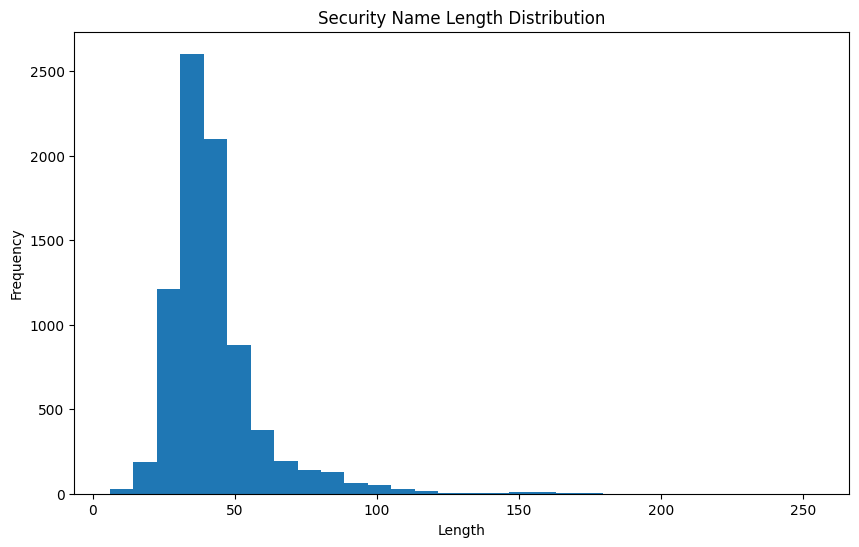

In [29]:
# Length of company names
df['Name Length'] = df['Security Name'].str.len()

plt.hist(df['Name Length'], bins=30)
plt.title('Security Name Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

# 16. Basic Insights from Univariate Analysis

# 17. Bivariate Analysis

## Relationship 1: ETF vs Listing Exchange

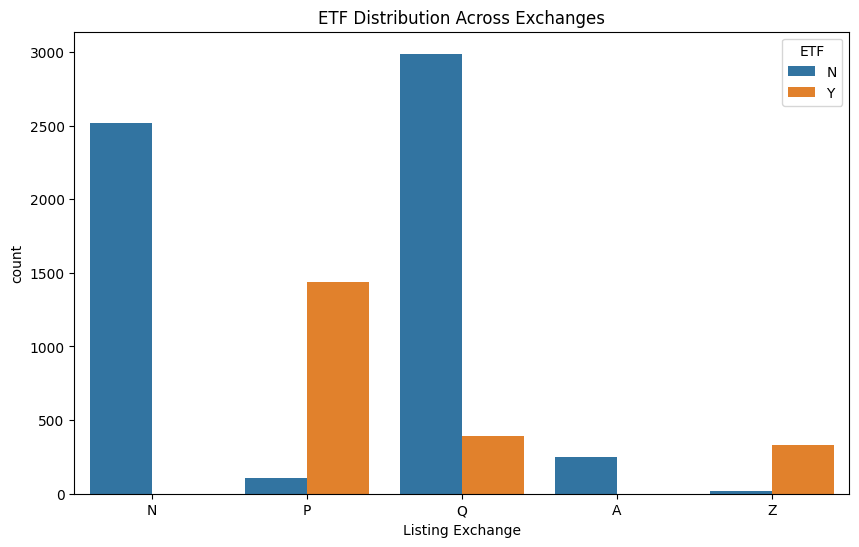

In [30]:
plt.figure(figsize=(10,6))
sns.countplot(x='Listing Exchange', hue='ETF', data=df)
plt.title('ETF Distribution Across Exchanges')
plt.show()

## Relationship 2: Market Category vs Nasdaq Traded

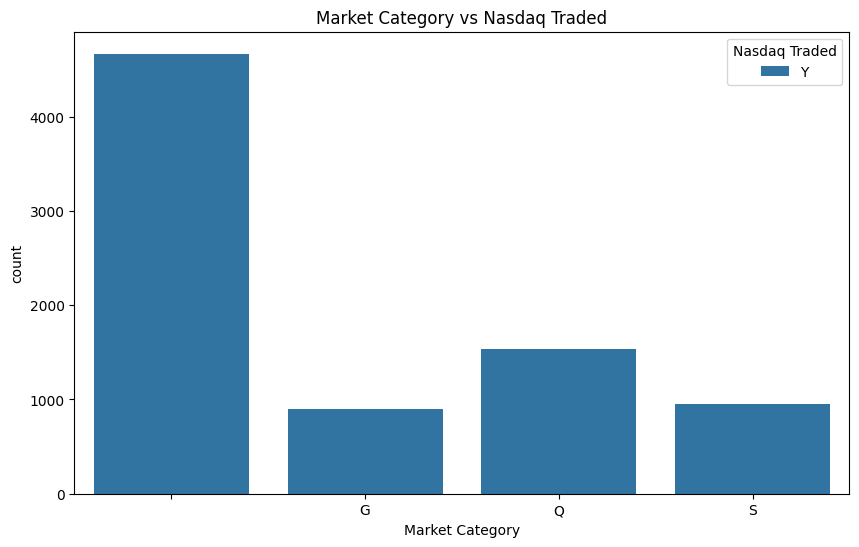

In [31]:
plt.figure(figsize=(10,6))
sns.countplot(x='Market Category', hue='Nasdaq Traded', data=df)
plt.title('Market Category vs Nasdaq Traded')
plt.show()

## Relationship 3: Round Lot Size vs ETF (Boxplot)

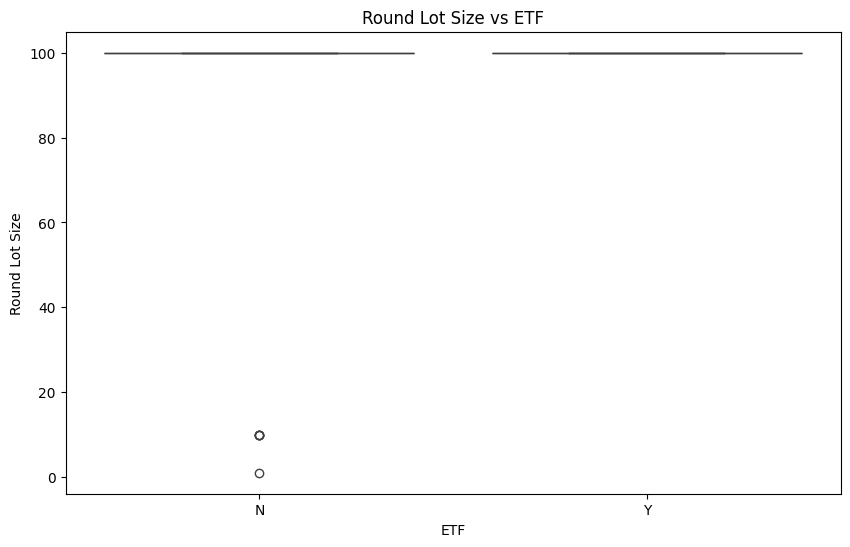

In [33]:
sns.boxplot(x='ETF', y='Round Lot Size', data=df)
plt.title('Round Lot Size vs ETF')
plt.show()

## Relationship 4: Exchange vs Test Issue

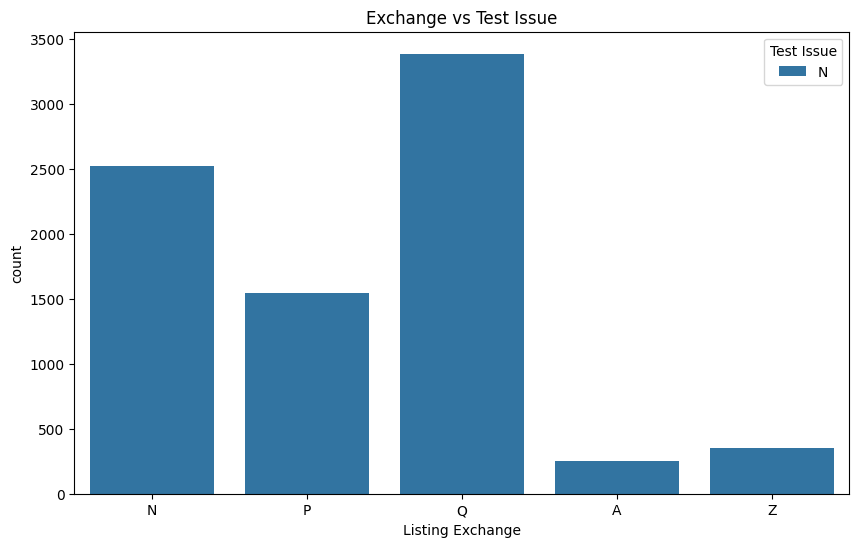

In [34]:
sns.countplot(x='Listing Exchange', hue='Test Issue', data=df)
plt.title('Exchange vs Test Issue')
plt.show()

## Relationship 5: Financial Status vs ETF

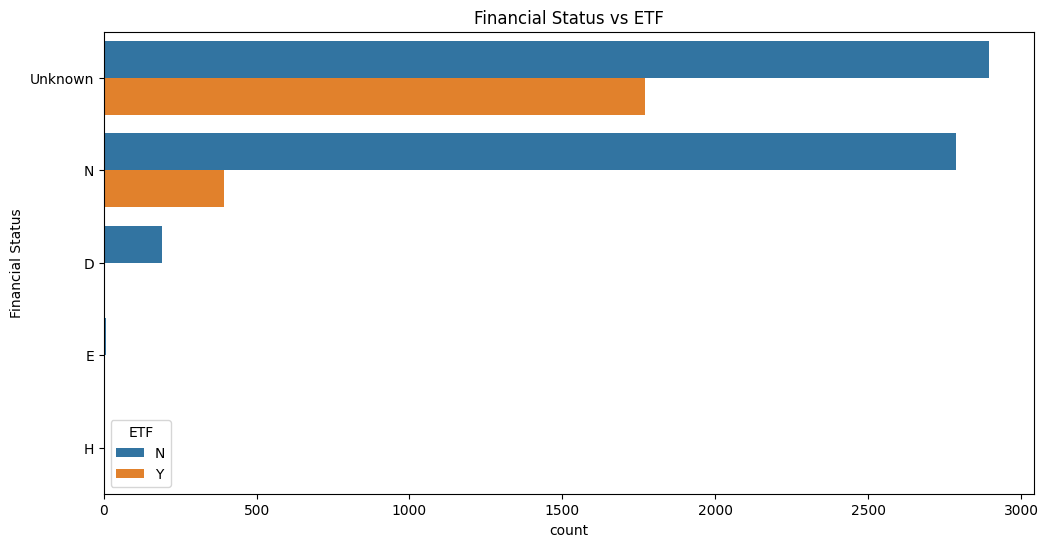

In [35]:
plt.figure(figsize=(12,6))
sns.countplot(y='Financial Status', hue='ETF', data=df)
plt.title('Financial Status vs ETF')
plt.show()

# 18. Multivariate Analysis

## Heatmap of Correlation

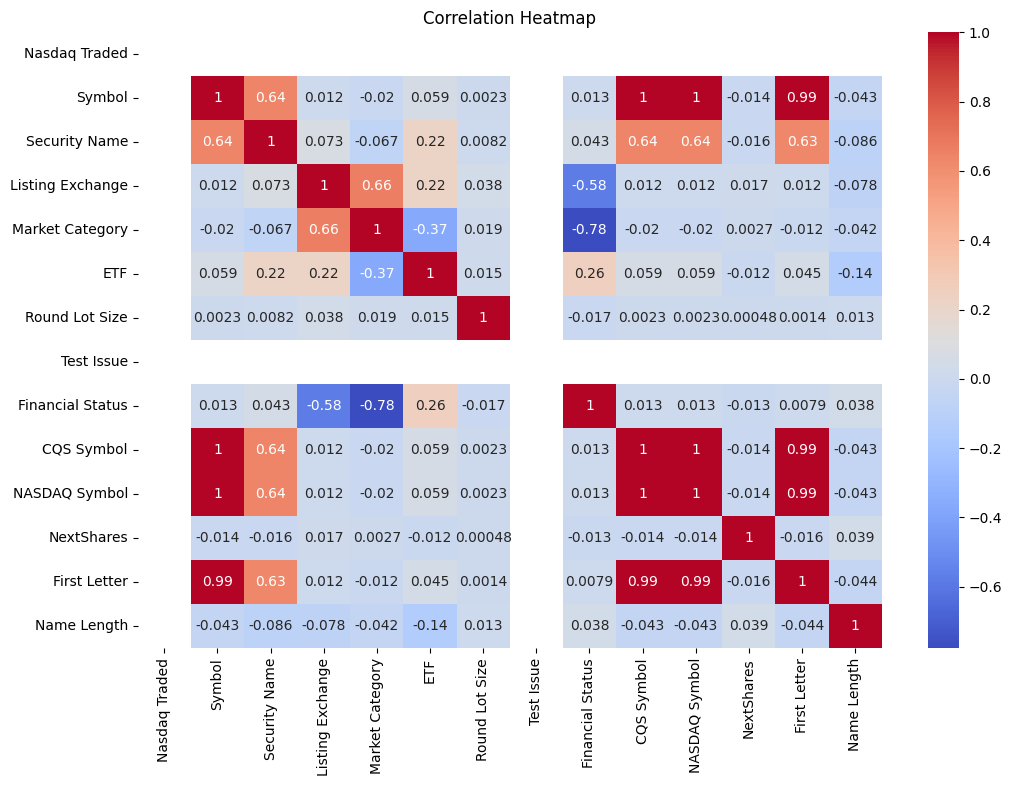

In [36]:
# Encoding categorical columns
encoded_df = df.copy()

for col in encoded_df.select_dtypes(include='object').columns:
    encoded_df[col] = encoded_df[col].astype('category').cat.codes

# Correlation matrix
corr = encoded_df.corr()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# GroupBy Analysis 1

In [37]:
exchange_group = df.groupby('Listing Exchange')['Round Lot Size'].mean().sort_values(ascending=False)
print(exchange_group)

Listing Exchange
P    100.000000
Q    100.000000
Z    100.000000
N     99.892857
A     99.252964
Name: Round Lot Size, dtype: float64


# GroupBy Analysis 2

In [38]:
etf_exchange = df.groupby('Listing Exchange')['ETF'].value_counts()
print(etf_exchange)

Listing Exchange  ETF
A                 N       252
                  Y         1
N                 N      2520
P                 Y      1435
                  N       107
Q                 N      2988
                  Y       395
Z                 Y       334
                  N        17
Name: count, dtype: int64


# GroupBy Analysis 3

In [39]:
financial_market = df.groupby('Market Category')['Financial Status'].value_counts()
print(financial_market)

Market Category  Financial Status
                 Unknown             4666
G                N                    882
                 D                     16
                 E                      2
Q                N                   1517
                 D                     11
                 E                      3
S                N                    781
                 D                    164
                 H                      4
                 E                      3
Name: count, dtype: int64


In [40]:
# New feature
df['Symbol Length'] = df['Symbol'].str.len()

print(df[['Symbol', 'Symbol Length']].head())

  Symbol  Symbol Length
0      A              1
1     AA              2
2   AAAU              4
3   AACG              4
4   AADR              4


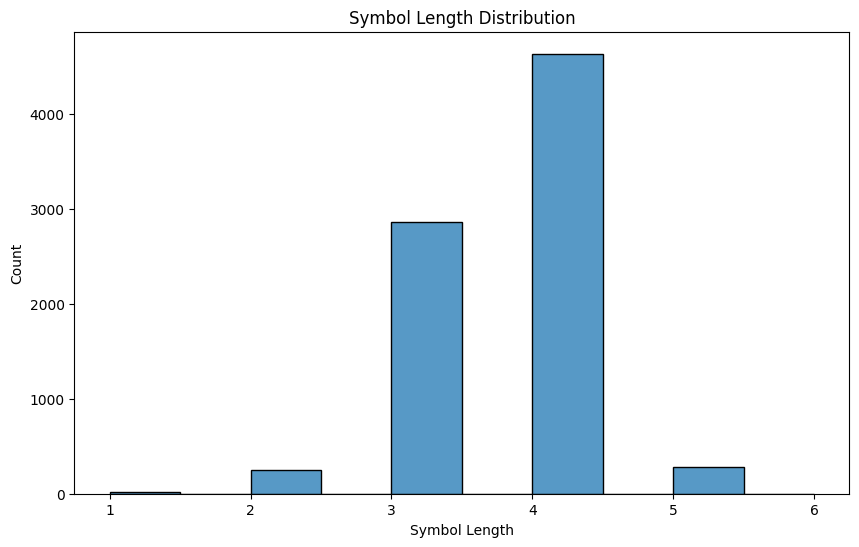

In [41]:
sns.histplot(df['Symbol Length'], bins=10)
plt.title('Symbol Length Distribution')
plt.show()

# 19. Advanced Data Scientist Insights

# 20. Final Conclusions


Key Findings
Most securities are Nasdaq traded.
Round Lot Size = 100 is industry standard.
Non-ETF securities dominate the market.
Exchanges differ significantly in security distribution.
Symbol inconsistencies are extremely rare.
Financial Status contains many missing/unknown values.

# 21. Final Cleaned Dataset Export

In [42]:
# Save cleaned dataset
df.to_csv('cleaned_stock_market_dataset.csv', index=False)